▶ 로드 완료: 3,418행 | 컬럼: ['대여소_ID', '주소1', '주소2', '위도', '경도']
▶ 유효 좌표 행: 3,341개
▶ GeoJSON 로드: 25개 구  |  구 이름 키: 'name'

▶ 구별 따릉이 대여소 수 (상위 10):
  gu  station_count
 송파구            246
 강서구            246
영등포구            215
 강남구            196
 노원구            174
 서초구            169
 종로구            155
 강동구            145
 마포구            132
 구로구            130

✅ 저장 완료: ddareungi_geomap.png
✅ 결과 저장: result_ddareungi_by_gu.csv


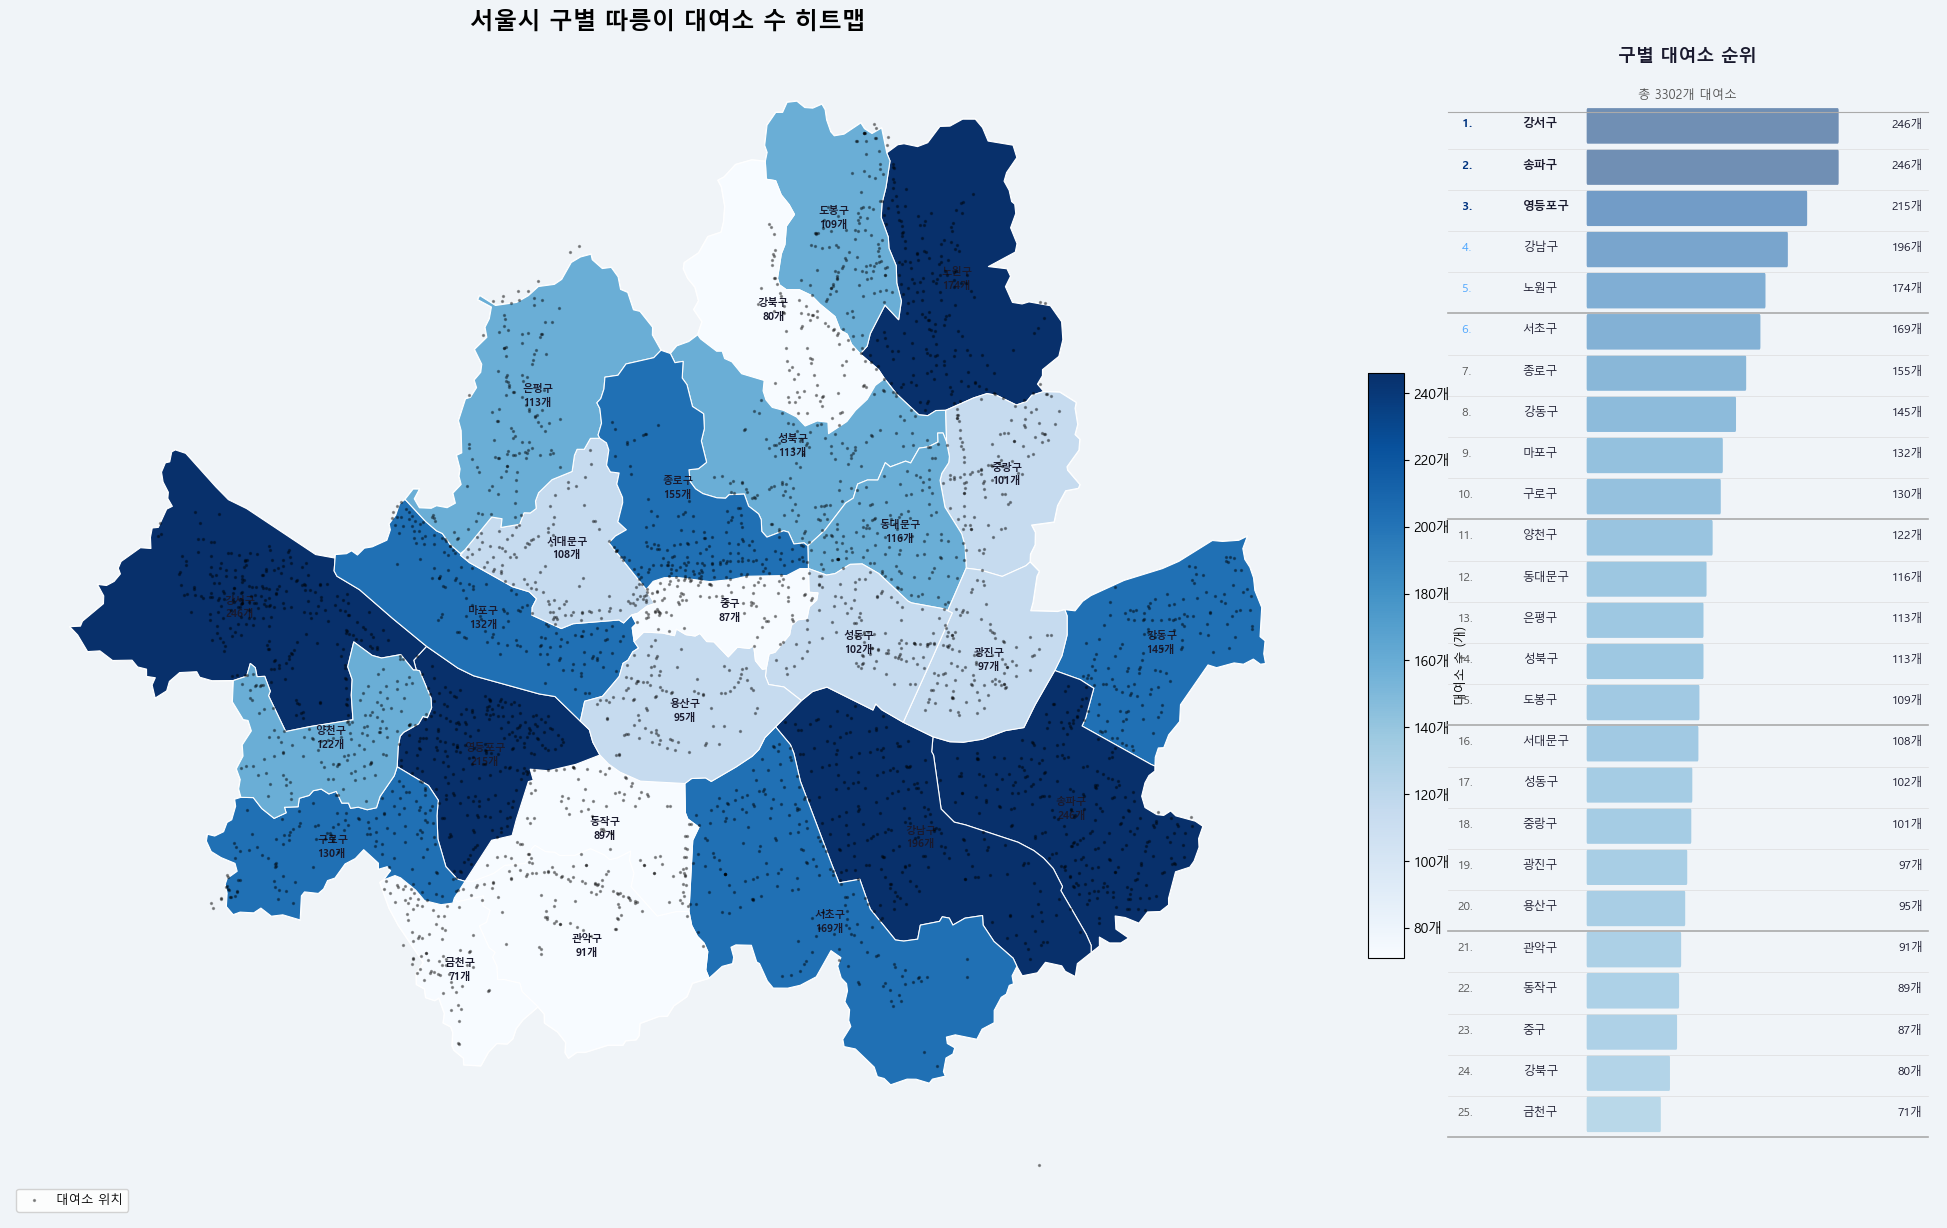

In [1]:
"""
따릉이 대여소 위치 → 구별 대여소 수 집계 → 서울 지도 히트맵

컬럼: 대여소_ID / 주소1 / 주소2 / 위도 / 경도

설치:
  pip install pandas geopandas matplotlib mapclassify shapely requests
실행:
  python ddareungi_geomap.py
"""

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import matplotlib.patches as mpatches
import os, urllib.request, warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════
# 0. 파일 경로  ← 실제 파일명으로 변경
# ══════════════════════════════════════════════════════
CSV_PATH = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\서울시 공공자전거 따릉이 대여소 마스터 정보.csv"


# ══════════════════════════════════════════════════════
# 1. 한글 폰트
# ══════════════════════════════════════════════════════
import matplotlib.font_manager as fm
def set_korean_font():
    for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    plt.rcParams["axes.unicode_minus"] = False
set_korean_font()


# ══════════════════════════════════════════════════════
# 2. CSV 로드
# ══════════════════════════════════════════════════════
for enc in ["utf-8-sig", "euc-kr", "cp949"]:
    try:
        df = pd.read_csv(CSV_PATH, encoding=enc)
        break
    except Exception:
        continue

df.columns = df.columns.str.strip()
print(f"▶ 로드 완료: {len(df):,}행 | 컬럼: {list(df.columns)}")

# 위도/경도 컬럼 자동 탐지
LAT_COL = next(c for c in df.columns if "위도" in c or c.lower() in ["lat","latitude"])
LNG_COL = next(c for c in df.columns if "경도" in c or c.lower() in ["lng","lon","longitude"])

df[LAT_COL] = pd.to_numeric(df[LAT_COL], errors="coerce")
df[LNG_COL] = pd.to_numeric(df[LNG_COL], errors="coerce")

# 위도/경도 0 또는 결측 제거
df = df[(df[LAT_COL] > 30) & (df[LNG_COL] > 100)].copy()
print(f"▶ 유효 좌표 행: {len(df):,}개")


# ══════════════════════════════════════════════════════
# 3. GeoJSON 다운로드 & 구 경계 GeoDataFrame
# ══════════════════════════════════════════════════════
GEOJSON_URL  = (
    "https://raw.githubusercontent.com/southkorea/seoul-maps/"
    "master/kostat/2013/json/seoul_municipalities_geo_simple.json"
)
GEOJSON_PATH = "seoul_districts.geojson"

if not os.path.exists(GEOJSON_PATH):
    print("▶ GeoJSON 다운로드 중...")
    urllib.request.urlretrieve(GEOJSON_URL, GEOJSON_PATH)

gdf_gu = gpd.read_file(GEOJSON_PATH)

# 구 이름 컬럼 자동 탐지
GEO_KEY = next(
    (c for c in gdf_gu.columns if any(x in c.lower() for x in ["name","kor","nm"])),
    gdf_gu.columns[0]
)
gdf_gu = gdf_gu.rename(columns={GEO_KEY: "gu"})
gdf_gu = gdf_gu.set_crs(epsg=4326, allow_override=True)
print(f"▶ GeoJSON 로드: {len(gdf_gu)}개 구  |  구 이름 키: '{GEO_KEY}'")


# ══════════════════════════════════════════════════════
# 4. 대여소 좌표 → GeoDataFrame → Spatial Join으로 구 매핑
# ══════════════════════════════════════════════════════
gdf_stations = gpd.GeoDataFrame(
    df,
    geometry=[Point(lng, lat) for lat, lng in zip(df[LAT_COL], df[LNG_COL])],
    crs="EPSG:4326"
)

# Spatial Join: 각 대여소가 어느 구에 속하는지 매핑
joined = gpd.sjoin(gdf_stations, gdf_gu[["gu", "geometry"]],
                   how="left", predicate="within")

# 구별 대여소 수 집계
count_by_gu = (
    joined.groupby("gu").size()
    .reset_index(name="station_count")
)

gdf_map = gdf_gu.merge(count_by_gu, on="gu", how="left")
gdf_map["station_count"] = gdf_map["station_count"].fillna(0).astype(int)

print("\n▶ 구별 따릉이 대여소 수 (상위 10):")
print(gdf_map.nlargest(10, "station_count")[["gu","station_count"]].to_string(index=False))


# ══════════════════════════════════════════════════════
# 5. 시각화
# ══════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor("#f0f4f8")

# 지도 영역 (왼쪽 72%)
ax = fig.add_axes([0.01, 0.05, 0.69, 0.90])
ax.set_facecolor("#cce0f0")

# ── 배경 ──
gdf_map.plot(ax=ax, color="#e8f0fe", edgecolor="white", linewidth=1.2)

# ── Choropleth 히트맵 ──
gdf_map.plot(
    column="station_count",
    ax=ax,
    cmap="Blues",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.8,
    legend=False,
    missing_kwds={"color": "#cccccc"},
)

# ── 구 이름 + 대여소 수 레이블 ──
for _, row in gdf_map.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    ax.annotate(
        f"{row['gu']}\n{int(row['station_count'])}개",
        xy=(cx, cy),
        ha="center", va="center",
        fontsize=7.5,
        color="#1a1a2e",
        fontweight="bold",
        fontfamily="Malgun Gothic",
    )

# ── 대여소 위치 산점도 오버레이 ──
ax.scatter(
    gdf_stations.geometry.x,
    gdf_stations.geometry.y,
    s=2, color="black", alpha=0.35, zorder=5,
    label="대여소 위치"
)
ax.legend(loc="lower left", fontsize=9, framealpha=0.85)

# ── 컬러바 ──
norm = mcolors.Normalize(
    vmin=gdf_map["station_count"].min(),
    vmax=gdf_map["station_count"].max()
)
cax = fig.add_axes([0.705, 0.25, 0.018, 0.45])
cb  = ColorbarBase(cax, cmap=plt.cm.Blues, norm=norm, orientation="vertical")
cb.set_label("대여소 수 (개)", fontsize=9, fontfamily="Malgun Gothic")
cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}개"))

ax.set_title("서울시 구별 따릉이 대여소 수 히트맵", fontsize=17,
             fontweight="bold", pad=14, fontfamily="Malgun Gothic")
ax.axis("off")


# ══════════════════════════════════════════════════════
# 6. 우측 전체 순위 패널
# ══════════════════════════════════════════════════════
ax2 = fig.add_axes([0.74, 0.05, 0.25, 0.90])
ax2.axis("off")

ranked = (
    gdf_map[["gu","station_count"]]
    .sort_values("station_count", ascending=False)
    .reset_index(drop=True)
)
cnt_max = ranked["station_count"].max()

ax2.text(0.5, 1.00, "구별 대여소 순위",
         transform=ax2.transAxes, ha="center", va="top",
         fontsize=13, fontweight="bold", fontfamily="Malgun Gothic", color="#1a1a2e")
ax2.text(0.5, 0.965, f"총 {int(ranked['station_count'].sum())}개 대여소",
         transform=ax2.transAxes, ha="center", va="top",
         fontsize=9, fontfamily="Malgun Gothic", color="#555555")

ax2.plot([0.02, 0.98], [0.945, 0.945], color="#aaaaaa",
         linewidth=0.8, transform=ax2.transAxes, clip_on=False)

row_h = 0.88 / len(ranked)

for i, row in ranked.iterrows():
    y = 0.935 - i * row_h

    # 배경 바
    bar_w = (row["station_count"] / cnt_max) * 0.50
    rect = mpatches.FancyBboxPatch(
        (0.30, y - row_h * 0.42), bar_w, row_h * 0.75,
        boxstyle="round,pad=0.002",
        linewidth=0,
        facecolor=plt.cm.Blues(0.2 + 0.75 * row["station_count"] / cnt_max),
        alpha=0.55,
        transform=ax2.transAxes,
        clip_on=False,
    )
    ax2.add_patch(rect)

    # 순위
    rank_color = "#003380" if i < 3 else ("#4da6ff" if i < 6 else "#555555")
    ax2.text(0.04, y, f"{i+1:>2}.",
             transform=ax2.transAxes, va="center", ha="left",
             fontsize=8.5, fontfamily="Malgun Gothic",
             color=rank_color, fontweight="bold" if i < 3 else "normal")

    # 구 이름
    ax2.text(0.17, y, row["gu"],
             transform=ax2.transAxes, va="center", ha="left",
             fontsize=8.5, fontfamily="Malgun Gothic",
             color="#1a1a2e", fontweight="bold" if i < 3 else "normal")

    # 대여소 수
    ax2.text(0.97, y, f"{int(row['station_count'])}개",
             transform=ax2.transAxes, va="center", ha="right",
             fontsize=8.5, fontfamily="Malgun Gothic", color="#1a1a2e")

    # 구분선
    lw = 1.2 if (i + 1) % 5 == 0 else 0.5
    lc = "#aaaaaa" if (i + 1) % 5 == 0 else "#dddddd"
    yline = y - row_h * 0.6
    ax2.plot([0.02, 0.98], [yline, yline], color=lc,
             linewidth=lw, transform=ax2.transAxes, clip_on=False)


# ══════════════════════════════════════════════════════
# 7. 저장 & 출력
# ══════════════════════════════════════════════════════
SAVE_PATH = "ddareungi_geomap.png"
plt.savefig(SAVE_PATH, dpi=180, bbox_inches="tight")
print(f"\n✅ 저장 완료: {SAVE_PATH}")

ranked.to_csv("result_ddareungi_by_gu.csv", index=False, encoding="utf-8-sig")
print("✅ 결과 저장: result_ddareungi_by_gu.csv")

plt.show()

위치정보: 3341
상반기: 23905
하반기: 33430
전체 사용량: 57327
    대여소_ID  대여건수  반납건수
0    ST-10    74    72
1  ST-1001     6    16
2  ST-1002    12     3
3  ST-1003     3     0
4  ST-1004     3     2
최종 병합: 2599
저장 완료: bike_rent_geomap.png


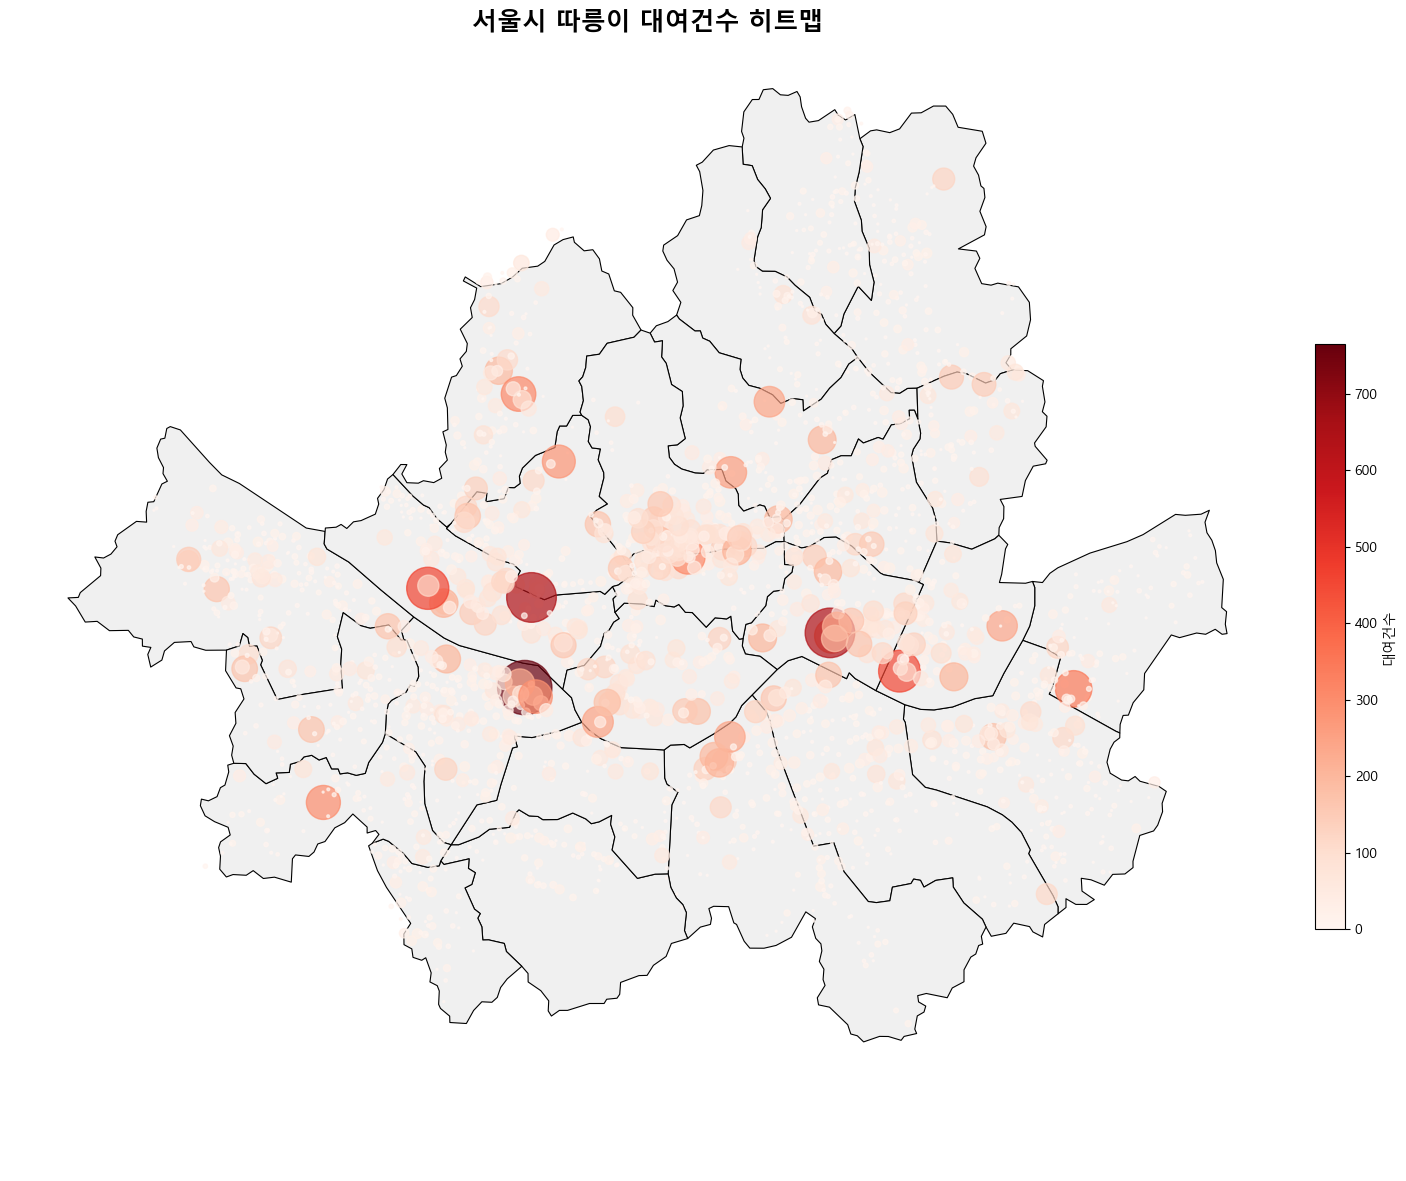

저장 완료: bike_return_geomap.png


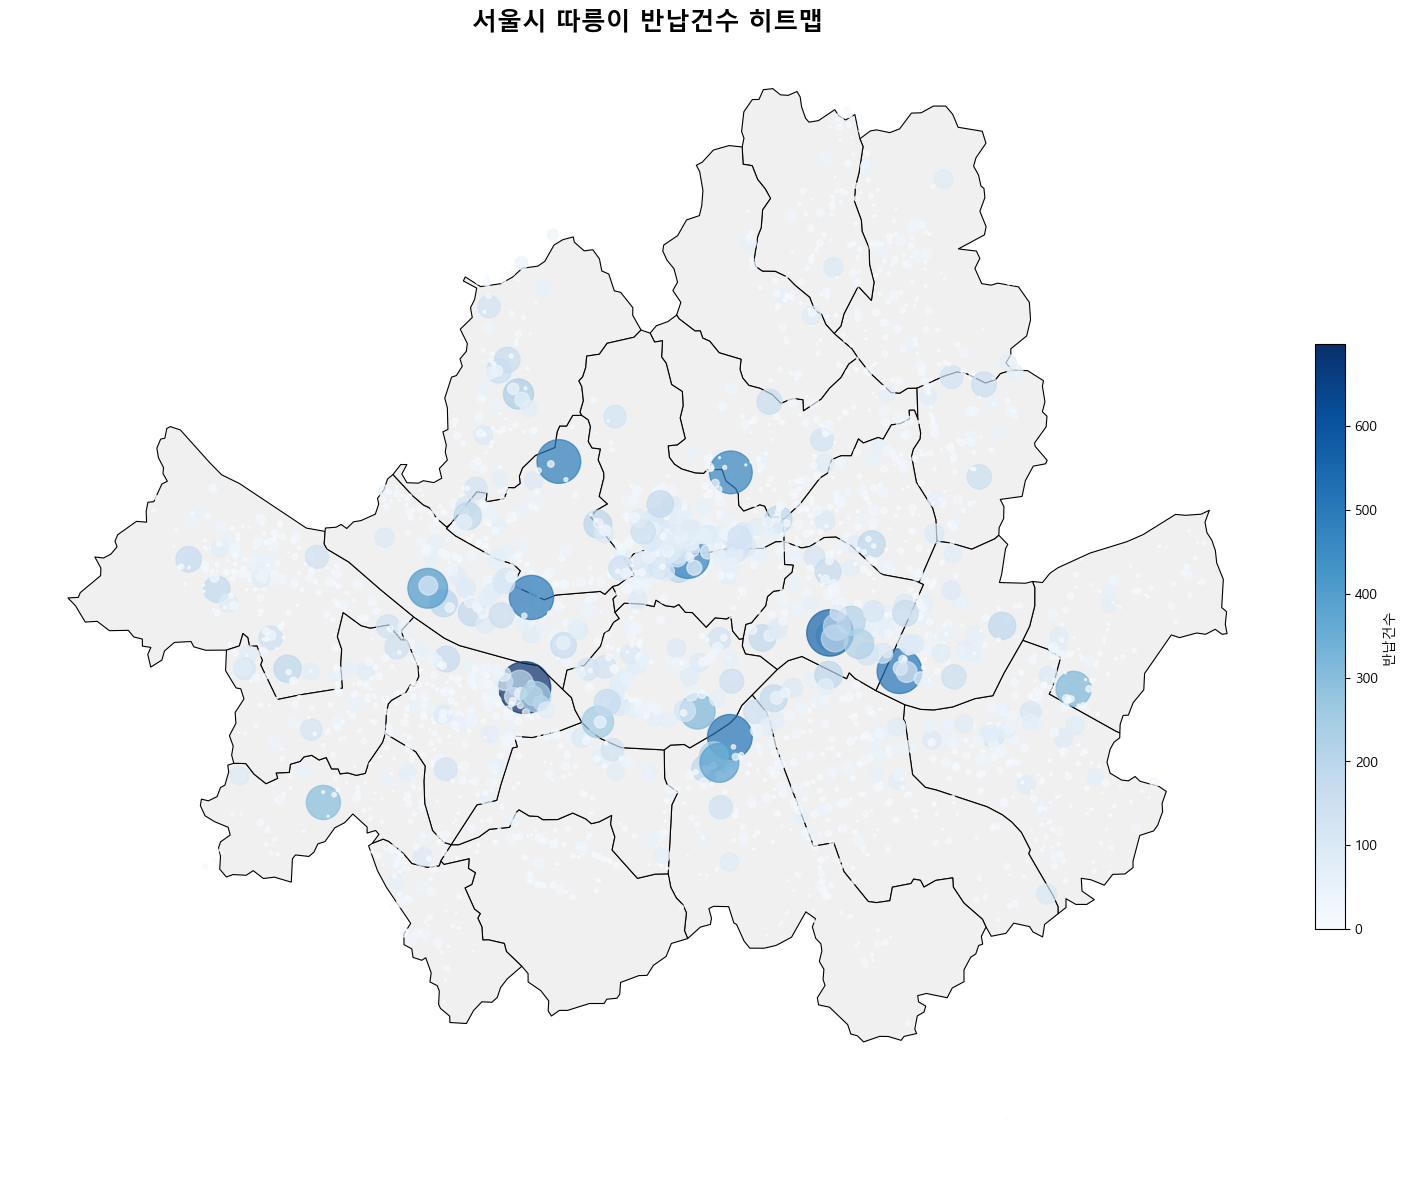

In [2]:
"""
따릉이 대여/반납 히트맵
(서울시 지도 + GeoMap 기반)

필요:
pip install pandas geopandas matplotlib mapclassify shapely requests
"""
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import matplotlib.font_manager as fm
import urllib.request
import os
import re
import warnings

warnings.filterwarnings("ignore")


# ======================================================
# 0. 파일 경로
# ======================================================

STATION_PATH = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\서울시 공공자전거 따릉이 대여소 마스터 정보.csv"

RENT_1_PATH = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\서울특별시 공공자전거 외국인 대여정보(일별)_25.1-6.csv"
RENT_2_PATH = r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\서울특별시 공공자전거 외국인 대여정보(일별)_25.7-12.csv"


# ======================================================
# 1. 한글 폰트
# ======================================================

import matplotlib.font_manager as fm

def set_korean_font():

    for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:

        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break

    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()


# ======================================================
# 2. CSV 로드 함수
# ======================================================

def load_csv(path):

    for enc in ["utf-8-sig", "euc-kr", "cp949"]:

        try:
            return pd.read_csv(path, encoding=enc)

        except:
            continue

    raise Exception(f"파일 로드 실패: {path}")


# ======================================================
# 2. CSV 로드 함수
# ======================================================

def load_csv(path):

    for enc in ["utf-8-sig", "euc-kr", "cp949"]:

        try:
            return pd.read_csv(path, encoding=enc)

        except:
            continue

    raise Exception(f"파일 로드 실패: {path}")


# ======================================================
# 3. 대여소 위치 데이터 로드
# ======================================================

station_df = load_csv(r"C:\Users\USER\OneDrive\바탕 화면\시각화 공모전 데이터\서울시 공공자전거 따릉이 대여소 마스터 정보.csv")

station_df.columns = station_df.columns.str.strip()

# 위도/경도 컬럼
LAT_COL = '위도'
LNG_COL = '경도'

station_df[LAT_COL] = pd.to_numeric(
    station_df[LAT_COL],
    errors='coerce'
)

station_df[LNG_COL] = pd.to_numeric(
    station_df[LNG_COL],
    errors='coerce'
)

# 유효 좌표만
station_df = station_df[
    (station_df[LAT_COL] > 30) &
    (station_df[LNG_COL] > 100)
].copy()

# ID 문자열화
station_df['대여소_ID'] = (
    station_df['대여소_ID']
    .astype(str)
    .str.strip()
)

print("위치정보:", len(station_df))


# ======================================================
# 5. 상반기 데이터
# ======================================================

rent1 = load_csv(RENT_1_PATH)

rent1.columns = rent1.columns.str.strip()

# 상반기는 이미 ST-xxx 형태
rent1['대여소_ID'] = (
    rent1['대여소명']
    .astype(str)
    .str.strip()
)

print("상반기:", len(rent1))


# ======================================================
# 6. 하반기 데이터
# ======================================================

rent2 = load_csv(RENT_2_PATH)

rent2.columns = rent2.columns.str.strip()

# 숫자 추출 함수
def extract_station_id(x):

    x = str(x)

    match = re.match(r'(\d+)', x)

    if match:
        return f"ST-{match.group(1)}"

    return None

rent2['대여소_ID'] = (
    rent2['대여소명']
    .apply(extract_station_id)
)

print("하반기:", len(rent2))


# ======================================================
# 7. 데이터 병합
# ======================================================

rent_df = pd.concat(
    [rent1, rent2],
    ignore_index=True
)

# ID 없는 것 제거
rent_df = rent_df.dropna(subset=['대여소_ID'])

print("전체 사용량:", len(rent_df))


# ======================================================
# 8. 대여소별 총합
# ======================================================

usage_df = rent_df.groupby('대여소_ID')[
    ['대여건수', '반납건수']
].sum().reset_index()

print(usage_df.head())


# ======================================================
# 9. 위치정보와 병합
# ======================================================

merged_df = pd.merge(
    station_df,
    usage_df,
    on='대여소_ID',
    how='inner'
)

print("최종 병합:", len(merged_df))


# ======================================================
# 10. 서울 GeoJSON 다운로드
# ======================================================

GEOJSON_URL = (
    "https://raw.githubusercontent.com/"
    "southkorea/seoul-maps/master/"
    "kostat/2013/json/"
    "seoul_municipalities_geo_simple.json"
)

GEOJSON_PATH = "seoul_districts.geojson"

if not os.path.exists(GEOJSON_PATH):

    urllib.request.urlretrieve(
        GEOJSON_URL,
        GEOJSON_PATH
    )

gdf_seoul = gpd.read_file(GEOJSON_PATH)

gdf_seoul = gdf_seoul.set_crs(
    epsg=4326,
    allow_override=True
)


# ======================================================
# 11. GeoDataFrame 생성
# ======================================================

gdf_bike = gpd.GeoDataFrame(
    merged_df,
    geometry=[
        Point(lng, lat)
        for lat, lng in zip(
            merged_df[LAT_COL],
            merged_df[LNG_COL]
        )
    ],
    crs="EPSG:4326"
)


# ======================================================
# 12. 히트맵 함수
# ======================================================

def draw_geomap(
    column_name,
    cmap_name,
    title,
    save_name
):

    fig = plt.figure(figsize=(15, 13))

    ax = fig.add_axes([0.02, 0.05, 0.85, 0.9])

    # 서울 지도
    gdf_seoul.plot(
        ax=ax,
        color="#f0f0f0",
        edgecolor="black",
        linewidth=0.8
    )

    # 히트맵
    gdf_bike.plot(
        column=column_name,
        ax=ax,
        cmap=cmap_name,
        markersize=gdf_bike[column_name] / 0.5,
        alpha=0.7,
        legend=False
    )

    # 컬러바
    norm = mcolors.Normalize(
        vmin=gdf_bike[column_name].min(),
        vmax=gdf_bike[column_name].max()
    )

    cax = fig.add_axes([0.89, 0.25, 0.02, 0.45])

    cb = ColorbarBase(
        cax,
        cmap=plt.get_cmap(cmap_name),
        norm=norm,
        orientation='vertical'
    )

    cb.set_label(column_name)

    ax.set_title(
        title,
        fontsize=18,
        fontweight='bold'
    )

    ax.axis('off')

    plt.savefig(
        save_name,
        dpi=180,
        bbox_inches='tight'
    )

    print(f"저장 완료: {save_name}")

    plt.show()


# ======================================================
# 13. 대여건수 히트맵
# ======================================================

draw_geomap(
    column_name='대여건수',
    cmap_name='Reds',
    title='서울시 따릉이 대여건수 히트맵',
    save_name='bike_rent_geomap.png'
)


# ======================================================
# 14. 반납건수 히트맵
# ======================================================

draw_geomap(
    column_name='반납건수',
    cmap_name='Blues',
    title='서울시 따릉이 반납건수 히트맵',
    save_name='bike_return_geomap.png'
)